/var/folders/vf/795h4sgx4wv_wlqvhkbksc100000gn/T/ipykernel_14091/4273139687.py:195: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Final concentrations:
Glucose:
  C_in(final)  = 4.9955 mol/m^3
  C_out(final) = 4.9955 mol/m^3
  J(final)     = 1.47935e-13 mol/m^2/s

Oxygen:
  C_in(final)  = 0.19982 mol/m^3
  C_out(final) = 0.19982 mol/m^3
  J(final)     = 4.61853e-15 mol/m^2/s

Uridine:
  C_in(final)  = 0.049955 mol/m^3
  C_out(final) = 0.049955 mol/m^3
  J(final)     = 1.15608e-15 mol/m^2/s

Adenosine:
  C_in(final)  = 0.019982 mol/m^3
  C_out(final) = 0.019982 mol/m^3
  J(final)     = 5.78204e-16 mol/m^2/s



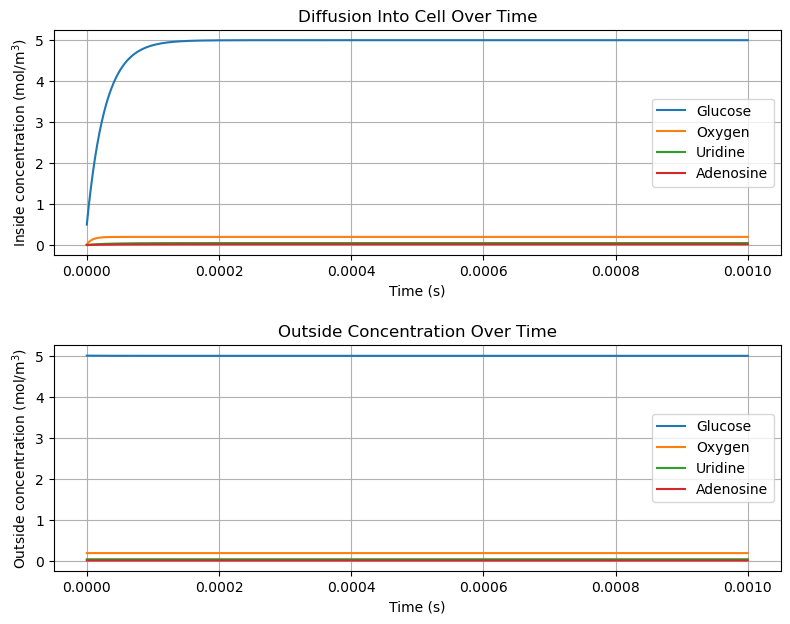

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Diffusion into the cell of media molecules from the batch reactor.
# Components diffused in: 
# Assumptions:
#  -cell and batch reactor are well mixed/homogenous so only assuming point diffusion across the cell wall and assuming the same diffusion for each cell in the batch reactor. 
#  -

# Using Fick's first law and letting concentrations of each molecule change as a function of time inside and outside of the cell
#   Starts with initial concentrations of each molecule.
#   Diffusion depends on surface area so this plays into the parameters.
#   Concentration changes depends on volumes inside and outside which is all the batch reactor liquid.


# INITIAL CONCENTRATIONS (mol/m^3)

#   Glucose
GLUCOSE_C_IN_0 = 0.5
GLUCOSE_C_OUT_0 = 5.0

#   Oxygen
OXYGEN_C_IN_0 = 0.02
OXYGEN_C_OUT_0 = 0.2

#   Uridine
URIDINE_C_IN_0 = 0.005
URIDINE_C_OUT_0 = 0.05

#   Adenosine 
ADENOSINE_C_IN_0 = 0.002
ADENOSINE_C_OUT_0 = 0.02



# CELL PARAMETERS

CELL_RADIUS = 10e-6 # meters (10 micrometers)
MEMBRANE_THICKNESS = 5e-9 # meters (5 nm)
OUTSIDE_VOLUME_MULTIPLIER = 1000
CELL_SURFACE_AREA = 4 * np.pi * CELL_RADIUS**2
CELL_VOLUME = (4/3) * np.pi * CELL_RADIUS**3
OUTSIDE_VOLUME = OUTSIDE_VOLUME_MULTIPLIER * CELL_VOLUME


# ============================================================
# DIFFUSION COEFFICIENTS
# Units: m^2 / s
# Replace any data as needed.
# ============================================================

#I'm using dictionaries because in EGR 105 they taught us that these are helpful for looping the same code with different parameters.
#Will let the code loop for each molecule separately. 

MOLECULES = {
    "Glucose": {
        "DiffusionCoefficient": 6.0e-10,
        "C_in_0": GLUCOSE_C_IN_0,
        "C_out_0": GLUCOSE_C_OUT_0,
    },
    "Oxygen": {
        "DiffusionCoefficient": 2.0e-9,
        "C_in_0": OXYGEN_C_IN_0,
        "C_out_0": OXYGEN_C_OUT_0,
    },
    "Uridine": {
        "DiffusionCoefficient": 5.2e-10,
        "C_in_0": URIDINE_C_IN_0,
        "C_out_0": URIDINE_C_OUT_0,
    },
    "Adenosine": {
        "DiffusionCoefficient": 4.8e-10,
        "C_in_0": ADENOSINE_C_IN_0,
        "C_out_0": ADENOSINE_C_OUT_0,
    },
}



# PARAMETERS FOR MODELING DIFFERENTIAL EQUATIONS

T_END = .001     # length of modeling diffusion (sec)
DT = 1e-8        # delta t size (sec)

# EQUATION FUNCTIONS

def membrane_flux(DiffusionCoefficient, C_out, C_in, L): #Fick's First law
    return DiffusionCoefficient * (C_out - C_in) / L #flux
        # positive J/flux is into the cell


#Finds current concentrations of molecule inside and outside of cell for forward euler
def derivatives(C_in, C_out, DiffusionCoefficient, area, V_in, V_out, L):
    J = membrane_flux(DiffusionCoefficient, C_out, C_in, L)

    dC_in_dt = (area / V_in) * J 
    dC_out_dt = -(area / V_out) * J

    return dC_in_dt, dC_out_dt

# FORWARD EULER

#Lets concentrations in/out and flux be stored as functions of time for graphing
def simulate_one_molecule(DiffusionCoefficient, C_in_0, C_out_0, area, V_in, V_out, L, t_end, dt):
    
    #Take steps based on desired modeling parameters set above
    n_steps = int(t_end / dt) + 1
    #time array that corresponds with concentration and flux arrays
    t = np.linspace(0, t_end, n_steps)

    #Initialize concentration and flux arrays to get them as functions of time
    C_in = np.zeros(n_steps)
    C_out = np.zeros(n_steps)
    J_vals = np.zeros(n_steps)

    C_in[0] = C_in_0
    C_out[0] = C_out_0
    J_vals[0] = membrane_flux(DiffusionCoefficient, C_out[0], C_in[0], L)

    for i in range(1, n_steps):
        
        #find new concentrations of molecule inside and outside of cell
        dC_in_dt, dC_out_dt = derivatives(
            C_in=C_in[i-1],
            C_out=C_out[i-1],
            DiffusionCoefficient=DiffusionCoefficient,
            area=area,
            V_in=V_in,
            V_out=V_out,
            L=L,
        )

        #updates concentration arrays with new concentration
        C_in[i] = C_in[i-1] + dt * dC_in_dt
        C_out[i] = C_out[i-1] + dt * dC_out_dt

        #updates flux array with new flux calculated with new concentrations
        J_vals[i] = membrane_flux(DiffusionCoefficient, C_out[i], C_in[i], L)

    return t, C_in, C_out, J_vals


results = {} #new dictionary for results of modeling

#find and store results for each molecule
for molecule_name, data in MOLECULES.items():
    t, C_in, C_out, J_vals = simulate_one_molecule(
        DiffusionCoefficient=data["DiffusionCoefficient"],
        C_in_0=data["C_in_0"],
        C_out_0=data["C_out_0"],
        area=CELL_SURFACE_AREA,
        V_in=CELL_VOLUME,
        V_out=OUTSIDE_VOLUME,
        L=MEMBRANE_THICKNESS,
        t_end=T_END,
        dt=DT
    )

    results[molecule_name] = {
        "t": t,
        "C_in": C_in,
        "C_out": C_out,
        "J": J_vals
    }

# PLOTTING

fig, (plt1, plt2) = plt.subplots(2,1, figsize=(8,6))
fig.tight_layout()
fig.subplots_adjust(hspace=0.4) #they were overlapping

# Inside concentration vs. time

for molecule_name, data in results.items():
    plt1.plot(data["t"], data["C_in"], label=molecule_name)

plt1.set_xlabel("Time (s)")
plt1.set_ylabel("Inside concentration (mol/m$^3$)")
plt1.set_title("Diffusion Into Cell Over Time")
plt1.legend()
plt1.grid(True)


# Outside concentration vs. time

for molecule_name, data in results.items():
    plt2.plot(data["t"], data["C_out"], label=molecule_name)

plt2.set_xlabel("Time (s)")
plt2.set_ylabel("Outside concentration (mol/m$^3$)")
plt2.set_title("Outside Concentration Over Time")
plt2.legend()
plt2.grid(True)

fig.show()


# Print concentrations at the end: 

print("Final concentrations:")
for molecule_name, data in results.items():
    print(f"{molecule_name}:")
    print(f"  C_in(final)  = {data['C_in'][-1]:.6g} mol/m^3")
    print(f"  C_out(final) = {data['C_out'][-1]:.6g} mol/m^3")
    print(f"  J(final)     = {data['J'][-1]:.6g} mol/m^2/s")
    print()